# Expectile Regularization (IQL) vs AFU: Actor-Free Critic Updates

Reproduction of **Figure 1** from:
> *AFU: Actor-Free critic Updates in off-policy RL for continuous control*
> Nicolas Perrin-Gilbert, arXiv:2404.16159v2

## Experiment

Both methods train `V_phi(s)` to approximate `s -> max_a Q_toy(s, a)` — the **max-Q problem**.

**Q function:** `Q_toy(s, a) = sin(4s) + 0.7*cos(4a)`,  `(s, a) in [-1, 1]^2`

**True maximum:** `V*(s) = sin(4s) + 0.7`  (since `max_a cos(4a) = 1`)

**Training:** 3000 gradient steps, batch size 256, uniform random `(s, a)` from `[-1,1]^2`.

---

### IQL Loss (Kostrikov et al., 2022)
Asymmetric L2 (expectile) regression on `delta = Q(s,a) - V(s)`:

    l_tau(delta) = |tau - 1[delta < 0]| * delta^2

- `tau = 0.5` -> mean regression
- `tau -> 1` -> V approaches max Q, but weight ratio `tau/(1-tau)` explodes -> instability in RL

### AFU Loss (Perrin-Gilbert, 2024)
Trains `V_phi(s)` jointly with `A_xi(s,a)` using **conditional gradient rescaling**:

    Lambda'(phi, xi) = E[ Z( Upsilon(s) - Q(s,a),  A_xi(s,a) ) ]

    Upsilon(s) = (1 - rho*I) * V(s) + rho*I * stop_grad(V(s))
    I = 1  if V(s) + A(s,a) < Q(s,a)  [underestimating]

    Z(x, y) = (x+y)^2   if x >= 0
             = x^2 + y^2  otherwise

- When overestimating (I=0): full gradient on V -> V decreases
- When underestimating (I=1): gradient on V scaled by (1-rho) -> V increases slowly
- Wide range of rho in [0.2, 0.7] works well — no instability


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import optax
import flax.linen as nn
from flax.training import train_state

np.random.seed(42)
print(f"JAX version: {jax.__version__}")
print(f"JAX devices: {jax.devices()}")

JAX version: 0.9.2
JAX devices: [CudaDevice(id=0), CudaDevice(id=1)]


In [2]:
# Q_toy and ground truth
# Q_toy(s, a) = sin(4s) + 0.7 * cos(4a),  (s, a) in [-1, 1]^2
# V*(s) = max_a Q_toy(s, a) = sin(4s) + 0.7  (since max cos(4a) = 1)


def Q_toy(s, a):
    return jnp.sin(4.0 * s) + 0.7 * jnp.cos(4.0 * a)


def V_star(s):
    return jnp.sin(4.0 * s) + 0.7


s_eval = jnp.linspace(-1.0, 1.0, 500)
v_true = V_star(s_eval)
print(f"V*(s) range: [{float(v_true.min()):.3f}, {float(v_true.max()):.3f}]")

V*(s) range: [-0.300, 1.700]


In [3]:
# MLP: 2 hidden layers x 256 units, ReLU — matches paper architecture


class MLP(nn.Module):
    hidden_size: int = 256
    output_size: int = 1

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(self.hidden_size)(x)
        x = nn.relu(x)
        x = nn.Dense(self.hidden_size)(x)
        x = nn.relu(x)
        x = nn.Dense(self.output_size)(x)
        return x.squeeze(-1)


def make_train_state(model, example_input, lr=3e-4, seed=0):
    params = model.init(jax.random.PRNGKey(seed), example_input)
    tx = optax.adam(lr)
    return train_state.TrainState.create(
        apply_fn=model.apply,
        params=params,
        tx=tx,
    )


v_model = MLP(hidden_size=256, output_size=1)  # V_phi: s -> R
a_model = MLP(hidden_size=256, output_size=1)  # A_xi: (s, a) -> R

_ex_s = jnp.zeros((1, 1))  # example input for V
_ex_sa = jnp.zeros((1, 2))  # example input for A

n_v = sum(
    x.size
    for x in jax.tree_util.tree_leaves(v_model.init(jax.random.PRNGKey(0), _ex_s))
)
n_a = sum(
    x.size
    for x in jax.tree_util.tree_leaves(a_model.init(jax.random.PRNGKey(0), _ex_sa))
)
print(f"V network: {n_v:,} parameters")
print(f"A network: {n_a:,} parameters")

V network: 66,561 parameters
A network: 66,817 parameters


In [4]:
# IQL Training
# Loss: l_tau(delta) = |tau - 1[delta < 0]| * delta^2,  delta = Q(s,a) - V(s)


@jax.jit
def iql_loss_fn(params, s_batch, a_batch, tau):
    V_s = v_model.apply(params, s_batch)
    Q_sa = Q_toy(s_batch[:, 0], a_batch[:, 0])
    delta = Q_sa - V_s
    weight = jnp.where(delta >= 0, tau, 1.0 - tau)
    return jnp.mean(weight * delta**2)


@jax.jit
def iql_step(state, s_batch, a_batch, tau):
    loss, grads = jax.value_and_grad(iql_loss_fn)(state.params, s_batch, a_batch, tau)
    return state.apply_gradients(grads=grads), loss


def train_iql(tau, n_steps=3000, batch_size=256, lr=3e-4, seed=0):
    rng = np.random.default_rng(seed)
    state = make_train_state(v_model, _ex_s, lr=lr, seed=seed)
    for _ in range(n_steps):
        s_b = jnp.array(rng.uniform(-1.0, 1.0, (batch_size, 1)).astype(np.float32))
        a_b = jnp.array(rng.uniform(-1.0, 1.0, (batch_size, 1)).astype(np.float32))
        state, _ = iql_step(state, s_b, a_b, tau)
    return np.array(v_model.apply(state.params, s_eval[:, None]))


iql_taus = [0.55, 0.75, 0.95, 0.99]
iql_results = {}
print("Training IQL...")
for tau in iql_taus:
    print(f"  tau={tau}...", end=" ", flush=True)
    iql_results[tau] = train_iql(tau, seed=42)
    print("done")
print("IQL complete.")

Training IQL...
  tau=0.55... done
  tau=0.75... done
  tau=0.95... done
  tau=0.99... done
IQL complete.


In [5]:
# AFU Training
# Trains V_phi and A_xi jointly with conditional gradient rescaling.
#
# Upsilon(s) = V(s) + rho * I * (stop_grad(V(s)) - V(s))
#   I = 1 when V(s) + A(s,a) < Q(s,a)  [underestimating]
#
# Z(x, y) = (x+y)^2 if x >= 0, else x^2 + y^2
#   x = Upsilon(s) - Q(s,a)
#   y = A_xi(s, a)


def afu_loss_fn(v_params, a_params, s_batch, a_batch, rho):
    Q_sa = Q_toy(s_batch[:, 0], a_batch[:, 0])
    V_s = v_model.apply(v_params, s_batch)
    A_sa = a_model.apply(a_params, jnp.concatenate([s_batch, a_batch], axis=-1))

    # indicator = 1 when underestimating (V + A < Q)
    indicator = jnp.where(V_s + A_sa < Q_sa, 1.0, 0.0)

    # Upsilon: conditionally stop gradient on V when underestimating
    V_sg = jax.lax.stop_gradient(V_s)
    Upsilon = V_s + rho * indicator * (V_sg - V_s)

    x = Upsilon - Q_sa  # V-side residual
    y = A_sa

    # Z(x, y)
    loss = jnp.where(x >= 0, (x + y) ** 2, x**2 + y**2)
    return jnp.mean(loss)


@jax.jit
def afu_step(v_state, a_state, s_batch, a_batch, rho):
    def combined(params):
        return afu_loss_fn(params[0], params[1], s_batch, a_batch, rho)

    loss, (v_grads, a_grads) = jax.value_and_grad(combined)(
        (v_state.params, a_state.params)
    )
    return (
        v_state.apply_gradients(grads=v_grads),
        a_state.apply_gradients(grads=a_grads),
        loss,
    )


def train_afu(rho, n_steps=3000, batch_size=256, lr=3e-4, seed=0):
    rng = np.random.default_rng(seed)
    v_state = make_train_state(v_model, _ex_s, lr=lr, seed=seed)
    a_state = make_train_state(a_model, _ex_sa, lr=lr, seed=seed + 1)
    for _ in range(n_steps):
        s_b = jnp.array(rng.uniform(-1.0, 1.0, (batch_size, 1)).astype(np.float32))
        a_b = jnp.array(rng.uniform(-1.0, 1.0, (batch_size, 1)).astype(np.float32))
        v_state, a_state, _ = afu_step(v_state, a_state, s_b, a_b, rho)
    return np.array(v_model.apply(v_state.params, s_eval[:, None]))


afu_rhos = [0.05, 0.2, 0.4, 0.7]
afu_results = {}
print("Training AFU...")
for rho in afu_rhos:
    print(f"  rho={rho}...", end=" ", flush=True)
    afu_results[rho] = train_afu(rho, seed=42)
    print("done")
print("AFU complete.")

Training AFU...
  rho=0.05... done
  rho=0.2... done
  rho=0.4... done
  rho=0.7... done
AFU complete.


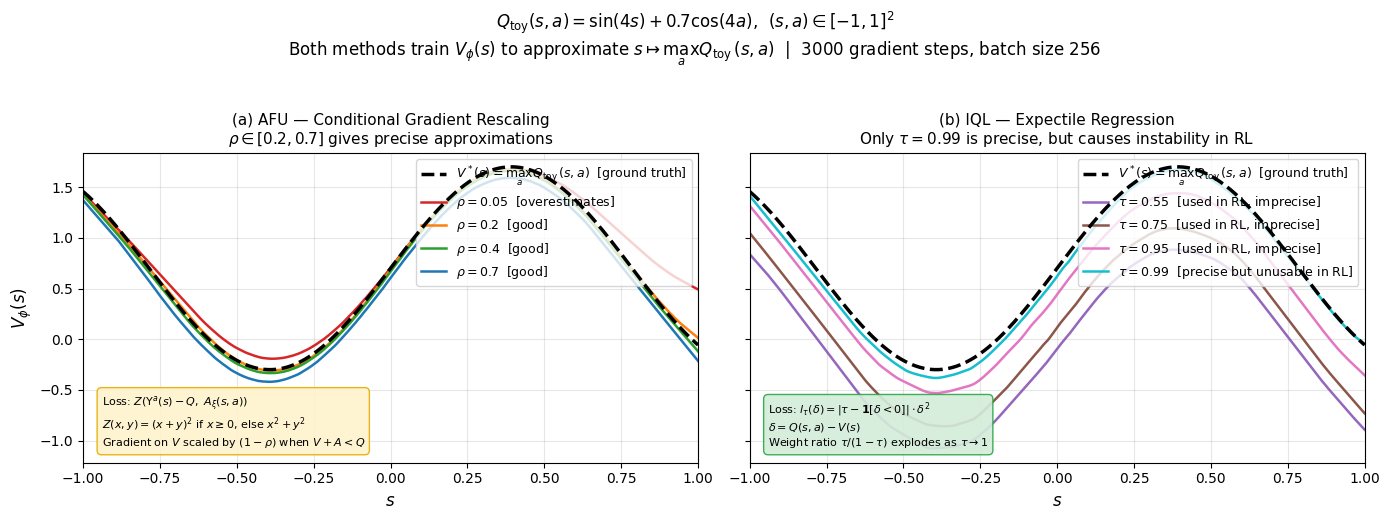

Saved: expectile_afu_fig1.png


In [6]:
# Figure 1 Reproduction — V_phi(s) vs true max_a Q_toy(s,a)

s_np = np.array(s_eval)
v_true_np = np.array(v_true)

afu_colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
iql_colors = ["#9467bd", "#8c564b", "#e377c2", "#17becf"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle(
    r"$Q_{\mathrm{toy}}(s, a) = \sin(4s) + 0.7\cos(4a)$,  $(s, a) \in [-1, 1]^2$"
    "\nBoth methods train $V_\\phi(s)$ to approximate "
    r"$s \mapsto \max_a Q_{\mathrm{toy}}(s, a)$"
    "  |  3000 gradient steps, batch size 256",
    fontsize=12,
    y=1.03,
)

# Panel (a): AFU
ax = axes[0]
ax.plot(
    s_np,
    v_true_np,
    "k--",
    linewidth=2.5,
    label=r"$V^*(s) = \max_a Q_{\mathrm{toy}}(s,a)$  [ground truth]",
    zorder=10,
)
for rho, color in zip(afu_rhos, afu_colors):
    suffix = "  [good]" if rho in (0.2, 0.4, 0.7) else "  [overestimates]"
    ax.plot(
        s_np,
        afu_results[rho],
        color=color,
        linewidth=1.8,
        label=rf"$\rho = {rho}${suffix}",
    )
ax.set_title(
    "(a) AFU — Conditional Gradient Rescaling\n"
    r"$\rho \in [0.2, 0.7]$ gives precise approximations",
    fontsize=11,
)
ax.set_xlabel(r"$s$", fontsize=12)
ax.set_ylabel(r"$V_\phi(s)$", fontsize=12)
ax.legend(fontsize=9, loc="upper right")
ax.set_xlim(-1, 1)
ax.grid(True, alpha=0.3)
ax.text(
    0.03,
    0.04,
    "Loss: $Z(\\Upsilon^a(s) - Q,\\; A_\\xi(s,a))$\n"
    "$Z(x,y) = (x+y)^2$ if $x \\geq 0$, else $x^2 + y^2$\n"
    "Gradient on $V$ scaled by $(1-\\rho)$ when $V+A < Q$",
    transform=ax.transAxes,
    fontsize=8,
    verticalalignment="bottom",
    bbox=dict(
        boxstyle="round,pad=0.4", facecolor="#fff3cd", alpha=0.9, edgecolor="#e6ac00"
    ),
)

# Panel (b): IQL
ax = axes[1]
ax.plot(
    s_np,
    v_true_np,
    "k--",
    linewidth=2.5,
    label=r"$V^*(s) = \max_a Q_{\mathrm{toy}}(s,a)$  [ground truth]",
    zorder=10,
)
for tau, color in zip(iql_taus, iql_colors):
    if tau == 0.99:
        suffix = "  [precise but unusable in RL]"
    else:
        suffix = "  [used in RL, imprecise]"
    ax.plot(
        s_np,
        iql_results[tau],
        color=color,
        linewidth=1.8,
        label=rf"$\tau = {tau}${suffix}",
    )
ax.set_title(
    "(b) IQL — Expectile Regression\n"
    r"Only $\tau = 0.99$ is precise, but causes instability in RL",
    fontsize=11,
)
ax.set_xlabel(r"$s$", fontsize=12)
ax.legend(fontsize=9, loc="upper right")
ax.set_xlim(-1, 1)
ax.grid(True, alpha=0.3)
ax.text(
    0.03,
    0.04,
    r"Loss: $l_\tau(\delta) = |\tau - \mathbf{1}[\delta < 0]| \cdot \delta^2$" + "\n"
    r"$\delta = Q(s,a) - V(s)$" + "\n"
    r"Weight ratio $\tau/(1-\tau)$ explodes as $\tau \to 1$",
    transform=ax.transAxes,
    fontsize=8,
    verticalalignment="bottom",
    bbox=dict(
        boxstyle="round,pad=0.4", facecolor="#d4edda", alpha=0.9, edgecolor="#28a745"
    ),
)

plt.tight_layout()
plt.savefig("expectile_afu_fig1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: expectile_afu_fig1.png")

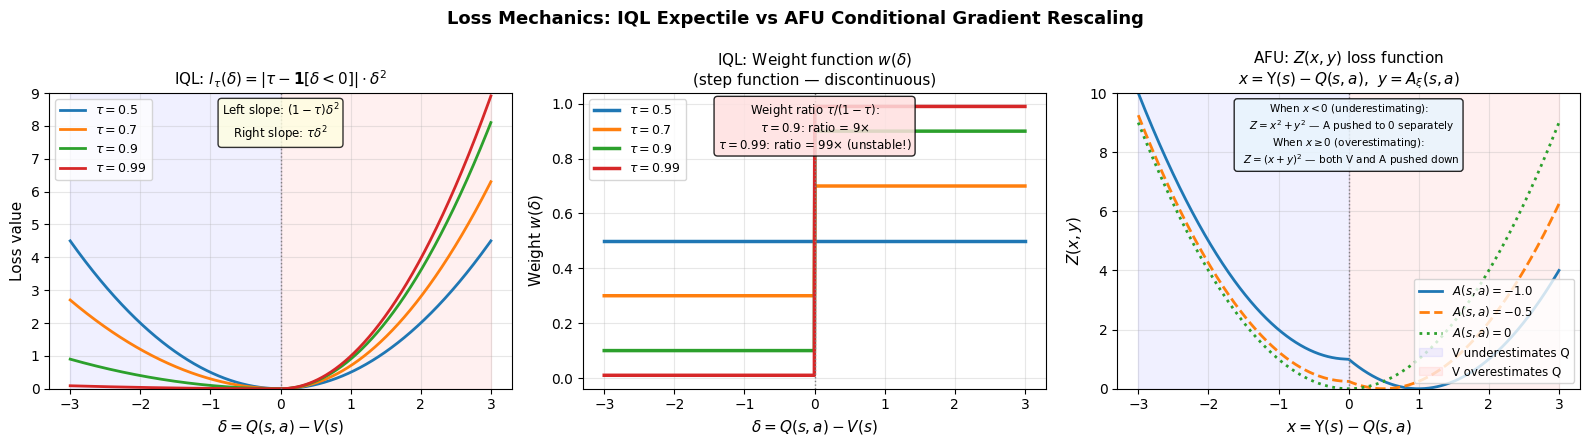

Saved: expectile_afu_mechanics.png


In [7]:
# Loss Mechanics Comparison
# Shows WHY IQL becomes unstable at high tau and AFU does not

delta = np.linspace(-3.0, 3.0, 1000)

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4.5))
fig2.suptitle(
    "Loss Mechanics: IQL Expectile vs AFU Conditional Gradient Rescaling",
    fontsize=13,
    fontweight="bold",
)

# Panel 1: IQL loss shape l_tau(delta)
ax = axes2[0]
taus_plot = [0.5, 0.7, 0.9, 0.99]
tau_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
for tau, c in zip(taus_plot, tau_colors):
    weight = np.where(delta >= 0, tau, 1.0 - tau)
    ax.plot(delta, weight * delta**2, color=c, linewidth=2, label=rf"$\tau={tau}$")
ax.axvline(0, color="gray", linestyle=":", linewidth=1)
ax.fill_betweenx([0, 9], -3, 0, alpha=0.06, color="blue")
ax.fill_betweenx([0, 9], 0, 3, alpha=0.06, color="red")
ax.set_title(
    r"IQL: $l_\tau(\delta) = |\tau - \mathbf{1}[\delta<0]| \cdot \delta^2$", fontsize=11
)
ax.set_xlabel(r"$\delta = Q(s,a) - V(s)$", fontsize=11)
ax.set_ylabel("Loss value", fontsize=11)
ax.set_ylim(0, 9)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.text(
    0.5,
    0.97,
    "Left slope: $(1-\\tau)\\delta^2$\nRight slope: $\\tau\\delta^2$",
    transform=ax.transAxes,
    fontsize=8.5,
    ha="center",
    va="top",
    bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8),
)

# Panel 2: IQL weight function (step function)
ax = axes2[1]
for tau, c in zip(taus_plot, tau_colors):
    weight = np.where(delta >= 0, tau, 1.0 - tau)
    ax.plot(delta, weight, color=c, linewidth=2.5, label=rf"$\tau={tau}$")
ax.axvline(0, color="gray", linestyle=":", linewidth=1)
ax.set_title(
    "IQL: Weight function $w(\\delta)$\n(step function — discontinuous)", fontsize=11
)
ax.set_xlabel(r"$\delta = Q(s,a) - V(s)$", fontsize=11)
ax.set_ylabel(r"Weight $w(\delta)$", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.text(
    0.5,
    0.97,
    "Weight ratio $\\tau/(1-\\tau)$:\n"
    r"$\tau=0.9$: ratio = 9$\times$" + "\n"
    r"$\tau=0.99$: ratio = 99$\times$ (unstable!)",
    transform=ax.transAxes,
    fontsize=8.5,
    ha="center",
    va="top",
    bbox=dict(boxstyle="round", facecolor="#ffe0e0", alpha=0.85),
)

# Panel 3: AFU Z(x, y) function
ax = axes2[2]
x_vals = np.linspace(-3.0, 3.0, 1000)
for y_val, ls, lbl in [
    (-1.0, "-", r"$A(s,a) = -1.0$"),
    (-0.5, "--", r"$A(s,a) = -0.5$"),
    (0.0, ":", r"$A(s,a) = 0$"),
]:
    z = np.where(x_vals >= 0, (x_vals + y_val) ** 2, x_vals**2 + y_val**2)
    ax.plot(x_vals, z, linestyle=ls, linewidth=2, label=lbl)
ax.axvline(0, color="gray", linestyle=":", linewidth=1)
ax.fill_betweenx([0, 10], -3, 0, alpha=0.06, color="blue", label="V underestimates Q")
ax.fill_betweenx([0, 10], 0, 3, alpha=0.06, color="red", label="V overestimates Q")
ax.set_title(
    r"AFU: $Z(x, y)$ loss function" + "\n"
    r"$x = \Upsilon(s) - Q(s,a)$,  $y = A_\xi(s,a)$",
    fontsize=11,
)
ax.set_xlabel(r"$x = \Upsilon(s) - Q(s,a)$", fontsize=11)
ax.set_ylabel(r"$Z(x, y)$", fontsize=11)
ax.set_ylim(0, 10)
ax.legend(fontsize=8.5, loc="lower right")
ax.grid(True, alpha=0.3)
ax.text(
    0.5,
    0.97,
    "When $x < 0$ (underestimating):\n"
    "  $Z = x^2 + y^2$ — A pushed to 0 separately\n"
    "When $x \\geq 0$ (overestimating):\n"
    "  $Z = (x+y)^2$ — both V and A pushed down",
    transform=ax.transAxes,
    fontsize=7.5,
    ha="center",
    va="top",
    bbox=dict(boxstyle="round", facecolor="#e8f4fd", alpha=0.85),
)

plt.tight_layout()
plt.savefig("expectile_afu_mechanics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: expectile_afu_mechanics.png")